In [1]:
from RRTG_helpers import *
import pandas as pd
import numpy as np
import c_graph_lib.bin.tourny as tou

In [2]:
def iso_comp(n: int) -> None:
    quotent_list_upsets = list(map(num_upsets, digraphs.tournaments_nauty(n)))
    full_list_upsets = list(tou.upset_generator(int(n), int(0)))
    graphics_array([
        [
            histogram(
                quotent_list_upsets,
                align='mid',
                color='red',
                bins=max(quotent_list_upsets)+1
            ),
            histogram(
                full_list_upsets,
                align='mid',
                color='blue',
                bins=max(full_list_upsets)+1
            )
        ],
        [
            text(f"Quotented Probablity Space from graphs of order{n}\n" + 
                f"var(X/~) = {np.var(quotent_list_upsets)}\n E[X/~] = {np.average(quotent_list_upsets)}",
                (50,50),
                fontsize='small'
            ),
            text(f"Unquotented Probablity Space from graphs of order{n}\n" + 
                f"var(X) = {np.var(full_list_upsets)}\n E[X] = {np.average(full_list_upsets)}",
                (50,50),
                fontsize='small'
            )
        ]
    ]).show()

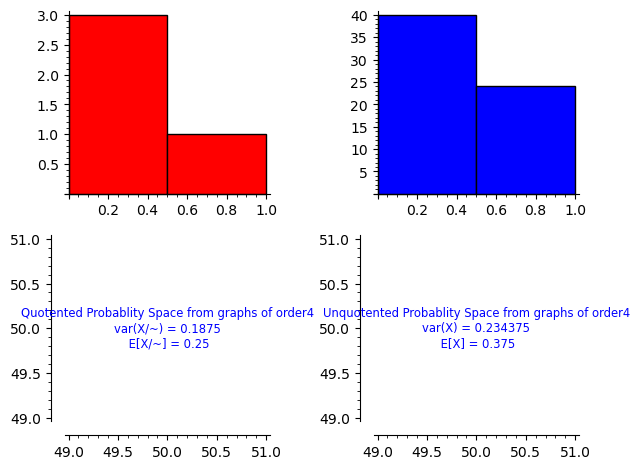

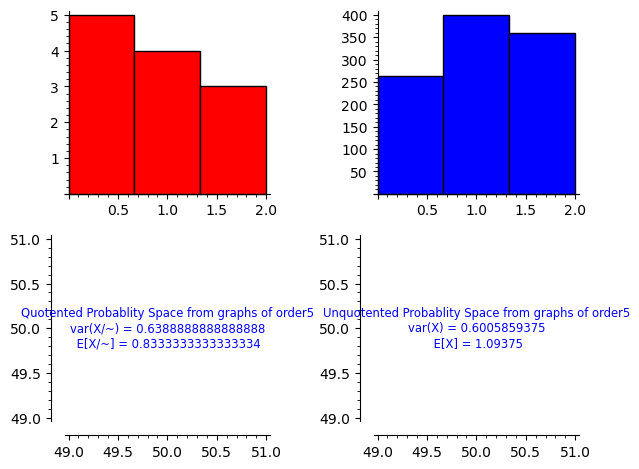

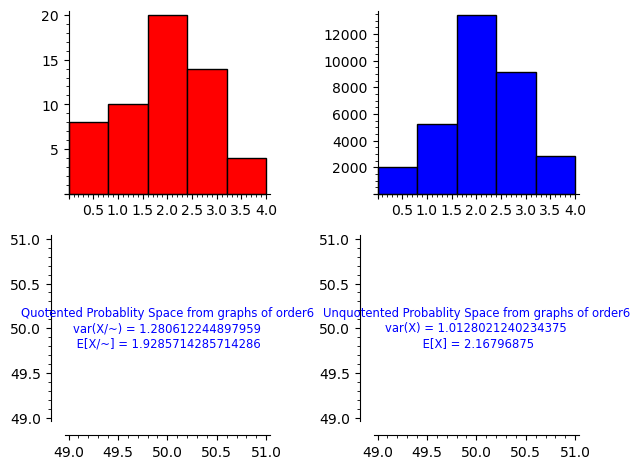

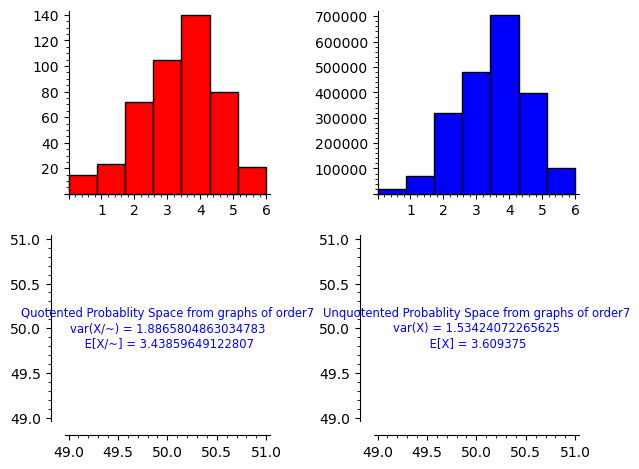

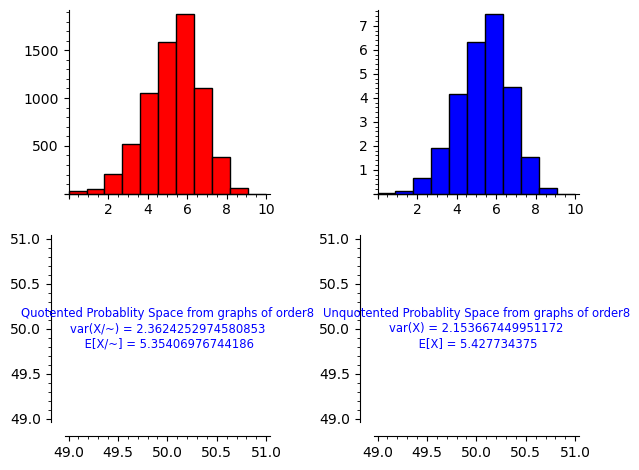

In [3]:
for i in range(4,9):
    iso_comp(i)

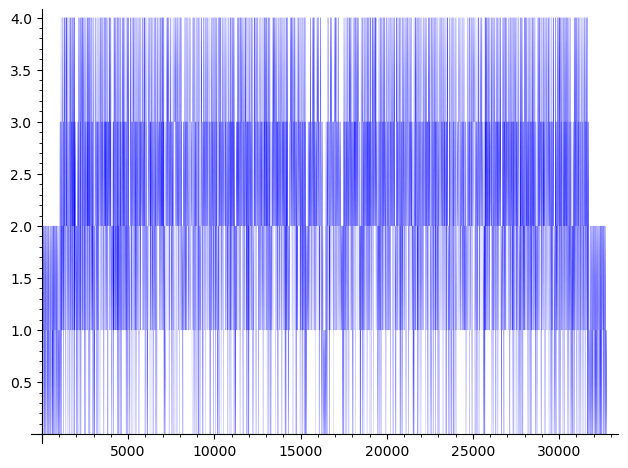

In [4]:
from sage.plot.line import line
line2d(list(enumerate(tou.upset_generator(int(6), int(0)))), thickness=0.04)

In [5]:
for n in range(2,7):
    print(f"{n} : {avg_var_upsets(n)}")

2 : (0, 0)
3 : (0, 0)
4 : (3/8, 15/64)
5 : (35/32, 615/1024)
6 : (555/256, 66375/65536)


In [6]:
order = int(4)
iso_class_ints = {TG : list() for TG in digraphs.tournaments_nauty(order, immutable=True)}
for g in tou.unnamed_TG(order):
    for iso_class in iso_class_ints:
        if iso_class.is_isomorphic(DiGraph(g.to_tuple(), immutable=True, format='list_of_edges')):
            iso_class_ints[iso_class].append(g.to_seed())
iso_class_ints

{Digraph on 4 vertices: [0,
  1,
  3,
  4,
  6,
  7,
  11,
  15,
  20,
  22,
  30,
  31,
  32,
  33,
  41,
  43,
  48,
  52,
  56,
  57,
  59,
  60,
  62,
  63],
 Digraph on 4 vertices: [2, 5, 27, 28, 40, 47, 49, 54],
 Digraph on 4 vertices: [9, 14, 16, 23, 35, 36, 58, 61],
 Digraph on 4 vertices: [8,
  10,
  12,
  13,
  17,
  18,
  19,
  21,
  24,
  25,
  26,
  29,
  34,
  37,
  38,
  39,
  42,
  44,
  45,
  46,
  50,
  51,
  53,
  55]}

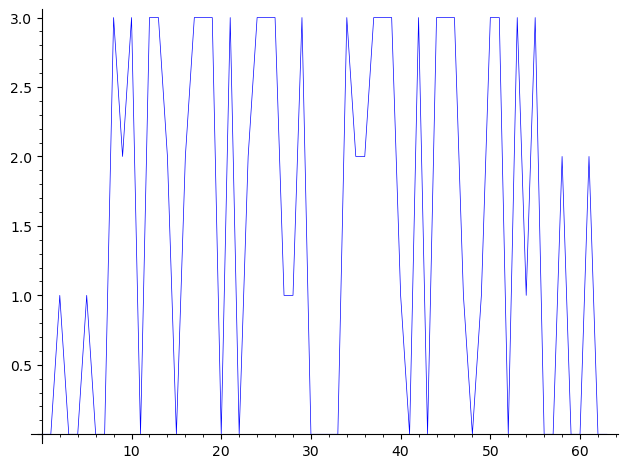

In [7]:
iso_class_graphs = [(graph_seed, i) for i,g in enumerate(iso_class_ints) for graph_seed in iso_class_ints[g]]
iso_class_graphs.sort()
line2d(iso_class_graphs, thickness=0.5)

In [8]:
iso_class_graphs

[(0, 0),
 (1, 0),
 (2, 1),
 (3, 0),
 (4, 0),
 (5, 1),
 (6, 0),
 (7, 0),
 (8, 3),
 (9, 2),
 (10, 3),
 (11, 0),
 (12, 3),
 (13, 3),
 (14, 2),
 (15, 0),
 (16, 2),
 (17, 3),
 (18, 3),
 (19, 3),
 (20, 0),
 (21, 3),
 (22, 0),
 (23, 2),
 (24, 3),
 (25, 3),
 (26, 3),
 (27, 1),
 (28, 1),
 (29, 3),
 (30, 0),
 (31, 0),
 (32, 0),
 (33, 0),
 (34, 3),
 (35, 2),
 (36, 2),
 (37, 3),
 (38, 3),
 (39, 3),
 (40, 1),
 (41, 0),
 (42, 3),
 (43, 0),
 (44, 3),
 (45, 3),
 (46, 3),
 (47, 1),
 (48, 0),
 (49, 1),
 (50, 3),
 (51, 3),
 (52, 0),
 (53, 3),
 (54, 1),
 (55, 3),
 (56, 0),
 (57, 0),
 (58, 2),
 (59, 0),
 (60, 0),
 (61, 2),
 (62, 0),
 (63, 0)]

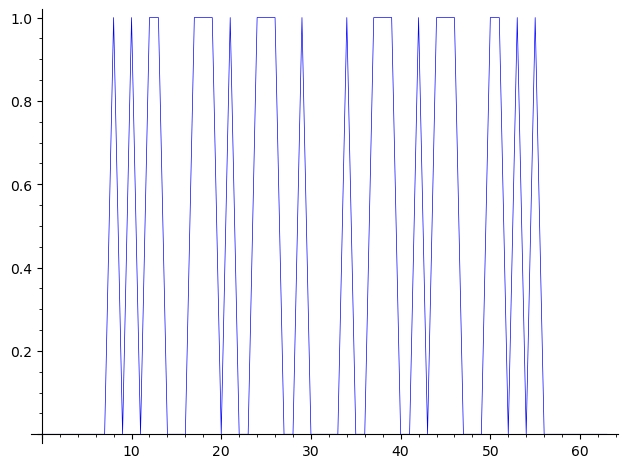

In [9]:
from sage.plot.line import line
point_list = list(enumerate(tou.upset_generator(int(4), int(0))))
line2d(point_list, thickness=0.5)